# Scenario catalog

Twenty representative driving scenarios encoded as DSL queries
and run against the corpus. The output is a ranked table of
candidate clip counts — clips that satisfy the necessary
conditions for that scenario.

> These queries are *necessary-condition filters*. They reject
> clearly-not-this-scenario candidates; a downstream classifier
> (VLM, human reviewer, heuristic) would disambiguate the
> survivors.

> See `01_quickstart.ipynb` for an introduction to the dataset
> and `02_query_dsl_tour.ipynb` for the DSL grammar.


## Setup


In [1]:
import os
from dataclasses import dataclass
from pathlib import Path

from cascade_av.dataset import CascadeDataset

# --- shared notebook styling -----------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

pd.options.display.max_colwidth = 110
pd.options.display.width = 140
pd.options.display.float_format = "{:.2f}".format


In [2]:
ds = CascadeDataset(Path(os.environ["CASCADE_AV_DATASET_ROOT"]))

@dataclass(frozen=True)
class Scenario:
    id: str
    title: str
    query: str


## The catalog

Twenty scenarios spanning pedestrian interactions, traffic
signals, signage, lane changes, junctions, and explicit
causal queries.


In [3]:
SCENARIOS = [
    Scenario("1",  "Ego drives on while a pedestrian is present (no yield)",
             "agent.type = ped and ego.action = drive"),
    Scenario("2",  "Ego yields/stops/brakes for a pedestrian",
             "agent.type = ped and ego.action in (stop, yield, decel)"),
    Scenario("8",  "Pedestrian jaywalks; ego brakes / yields",
             # Post-0.6.1, `Jaywalk` is a standalone action
             # (alias jaywalk_action); the combined-suffix forms
             # are deprecated but still match, so enumerate both.
             'agent(type = ped, action.type in ('
             '"Jaywalk", '
             '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
             '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)"'
             ')) and ego.action in (stop, yield, decel)'),
    Scenario("9",  "Pedestrian present while ego is turning",
             "agent.type = ped and ego.action in (turn_left, turn_right)"),
    Scenario("12", "Cyclist mid-block in ego's path; ego defensive",
             "agent.type = cyclist and ego.action in (stop, yield, decel)"),
    Scenario("14", "Ego stops at a red traffic light (nominal)",
             "light.color = red and ego.action = stop"),
    Scenario("16", "Ego proceeds through a green light",
             "light.color = green and ego.action = drive"),
    Scenario("20", "Ego already in intersection when yellow begins, proceeds",
             "light(color = yellow, ego_in_on_yellow = true) and ego.action in (drive, enter, creep)"),
    Scenario("21", "Ego approaches intersection, yellow appears, ego stops",
             "light(color = yellow, on_ego_path = true) and ego.action = stop"),
    Scenario("23", "Ego stops on yellow it could have cleared safely",
             "light(color = yellow, could_have_cleared = true) and ego.action = stop"),
    Scenario("aws-basic", "Ego stops at a stop sign",
             "obj.type = stop_sign and ego.action = stop"),
    Scenario("yield-basic", "Ego yields at a yield sign",
             "obj.type = yield_sign and ego.action = yield"),
    Scenario("76", "Stopped vehicle ahead; ego nudges or changes lane",
             "agent(type = vehicle, action(type in (stop, not_move))) "
             "and ego.action in (nudge, change_lane_left, change_lane_right)"),
    Scenario("lane-multi", "Multi-lane road, ego changes lane",
             "env(type = road, lanes >= 2) and ego.action in (change_lane_left, change_lane_right)"),
    Scenario("emergency-vehicle", "Emergency / hazard vehicle (flashing lights) present; ego brakes",
             "agent(type = vehicle, prop.source = flashing_light) "
             "and ego.action in (stop, yield, decel)"),
    Scenario("junction-turn", "Ego turns at a junction",
             "env.type = road and ego.action in (turn_left, turn_right)"),
    Scenario("vehicle-cut-in", "Vehicle cuts in / changes lane ahead; ego brakes",
             "agent(type = vehicle, action(type in (change_lane, change_lane_left, change_lane_right))) "
             "and ego.action in (decel, stop, nudge)"),
    Scenario("stop-because-red", "Ego stops BECAUSE OF a red light (causal edge)",
             "ego.action = stop because_of light.color = red"),
    Scenario("yellow-then-stop", "Yellow light followed by ego stop within 3s",
             "light.color = yellow then(3) ego.action = stop"),
    Scenario("red-without-stop", "During red light, ego never stops (potential violation)",
             "within light.color = red: not ego.action = stop"),
]
print(f"{len(SCENARIOS)} scenarios catalogued")


20 scenarios catalogued


## Run them all and tabulate

Sorted by candidate count, descending. The `example` column
shows one matching `clip_id` per scenario — drop it into the
annotation tool or `find_on_bundle` to inspect.


In [4]:
rows = []
for s in SCENARIOS:
    try:
        matches = ds.find(s.query)
        clips = sorted(set(matches.clips()))
        rows.append({
            "id":         s.id,
            "title":      s.title,
            "candidates": len(clips),
            "example":    clips[0] if clips else "",
        })
    except Exception as e:
        rows.append({
            "id":         s.id,
            "title":      s.title,
            "candidates": -1,
            "example":    f"ERROR: {e}",
        })

results = pd.DataFrame(rows).sort_values("candidates", ascending=False, ignore_index=True)
results


,id,title,candidates,example
0,2,Ego yields/stops/brakes for a pedestrian,76,0715f5b5-ab24-4c46-8a3f-a914ef80a812
1,1,Ego drives on while a pedestrian is present (no yield),73,0715f5b5-ab24-4c46-8a3f-a914ef80a812
2,16,Ego proceeds through a green light,64,05cb5aeb-b362-4f1a-b1b0-0e4b271fd081
3,14,Ego stops at a red traffic light (nominal),52,05cb5aeb-b362-4f1a-b1b0-0e4b271fd081
4,stop-because-red,Ego stops BECAUSE OF a red light (causal edge),45,05cb5aeb-b362-4f1a-b1b0-0e4b271fd081
5,emergency-vehicle,Emergency / hazard vehicle (flashing lights) present; ego brakes,30,05388c5d-db31-406e-bf62-7dbd1030413d
6,red-without-stop,"During red light, ego never stops (potential violation)",28,13bd8d8c-c76f-41fe-8321-6894ee3ca1c8
7,8,Pedestrian jaywalks; ego brakes / yields,26,164a3a68-074c-4795-b7ae-be9e58146347
8,20,"Ego already in intersection when yellow begins, proceeds",22,14f406a1-7c38-42ce-927a-adc6a6f5e718
9,76,Stopped vehicle ahead; ego nudges or changes lane,22,061e52a9-e953-4e4a-85c2-c723d897815f


## Visualise the distribution

A quick bar chart of candidate counts makes it obvious which
scenarios are well-represented in the corpus and which are
scarce.


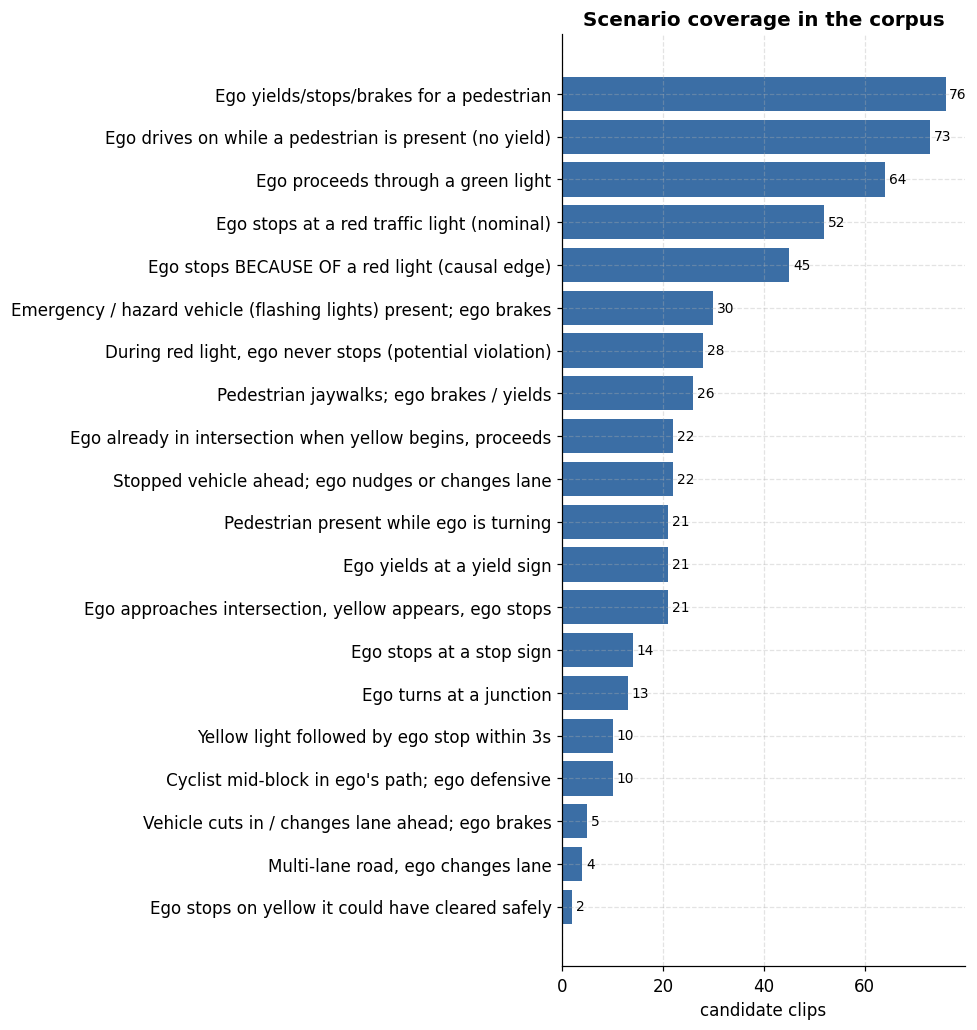

In [5]:
plot_df = results[results["candidates"] >= 0].sort_values("candidates", ascending=True)

fig, ax = plt.subplots(figsize=(9, 0.4 * len(plot_df) + 1.5))
ax.barh(plot_df["title"], plot_df["candidates"], color="#3b6ea5")
ax.set_xlabel("candidate clips")
ax.set_title("Scenario coverage in the corpus")
for i, v in enumerate(plot_df["candidates"].values):
    ax.text(v + max(plot_df["candidates"].max(), 1) * 0.01, i,
            str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Dig into one scenario

Pick a scenario, list every matching clip. Swap the `target`
query for any expression you want to drill into.


In [6]:
target = (
    'agent(type = ped, action.type in ('
    '"Jaywalk", '
    '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
    '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)"'
    ')) and ego.action in (stop, yield, decel)'
)
clips = sorted(set(ds.find(target).clips()))

print(f"{len(clips)} clips match: {target}\n")
pd.DataFrame({"clip_id": clips})


26 clips match: agent(type = ped, action.type in ("Jaywalk", "oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", "oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)")) and ego.action in (stop, yield, decel)



,clip_id
0,164a3a68-074c-4795-b7ae-be9e58146347
1,1ec9d3b0-4110-41bf-98b2-ba8bccd2fc05
2,31a809f4-ae3c-4b54-b147-402cf3454146
3,4ad7f342-f20d-48fc-bbd7-96061568e125
4,4e4d759f-1d98-4609-bcb9-6e627f711627
5,5c463500-9135-4a3c-8d6b-29640a72e383
6,5c465e99-a217-462b-94d9-4877e00f21d6
7,5f7fa314-d463-4113-9e09-66bc1c0f9df6
8,6065c42c-ad45-41eb-a6ba-749284225794
9,6236d59f-39f2-4eff-a61e-549e68cebc96
